### INTRODUCCION
#### En este trabajo práctico se utilizó una base de datos pública que contiene mediciones reales de calidad del agua en diferentes sectores del Río de la Plata. Los datos, disponibles en el portal del CIAM, incluyen información clave sobre diversas variables fisicoquímicas y microbiológicas.

#### Para abordar este objetivo, se utilizaron diversas librerías de Python, como pandas, numpy, scikit-learn, missingno, matplotlib y seaborn, entre otras. Una de las tareas principales consistió en la concatenación de varios archivos CSV correspondientes a diferentes años en un único DataFrame, seguida del preprocesamiento, ordenamiento y limpieza de los datos para optimizar su uso. Adicionalmente, se realizó un análisis exploratorio de los datos, utilizando gráficos y contrastes entre variables para identificar patrones, tendencias y posibles inconsistencias.

#### Nuestra base de datos final contiene 315 registros y 8 variables, las cuales incluyen:

#### -Temperatura del agua
#### -pH
#### -Presencia de olores
#### -Coliformes totales
#### -Nitrato
#### -Amonio
#### -Turbidez
#### -Presencia de derivados de hidrocarburos

#### Las categorizaciones de deterioro de agua estan implicitas en la base de datos

#### El objetivo principal del proyecto fue desarrollar un algoritmo que, basado en estas variables, permita clasificar muestras de agua desconocidas en una de las tres categorías de deterioro definidas: Deteriorada, Muy deteriorada y Extremadamente deteriorada.

#### Como desafío adicional, el proyecto implicó la recategorización de variables de tipo string a valores numéricos. Además, se realizó un análisis del grado de correlación entre las variables para identificar relaciones significativas y guiar la construcción de modelos.

#### Se probaron diferentes algoritmos de machine learning, evaluando su desempeño mediante la métrica de accuracy sobre muestras seleccionadas. Finalmente, el modelo que obtuvo el mejor desempeño fue Random Forest, gracias a su capacidad para ajustarse de manera efectiva a los datos reales y ofrecer un mejor puntaje en comparación con otros métodos.

#### Este enfoque busca aportar una herramienta eficiente para identificar la calidad del agua, facilitando la toma de decisiones en la gestión ambiental.

In [1]:
# Importamos los módulos
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import truncnorm
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
#sns.set_style('darkgrid')
plt.style.use('ggplot')
import warnings
warnings.filterwarnings('ignore')
import missingno 

In [2]:
# Abrimos los csv con los datos de calidad de agua del rio de la plata
df2018= pd.read_csv('agc_z_riodelaplata_2018.csv', sep= ';')
df2019= pd.read_csv('agc_z_riodelaplata_2019.csv', sep= ';')
df2020= pd.read_csv('agc_z_riodelaplata_2020.csv', sep= ';')
df2021= pd.read_csv('agc_z_riodelaplata_2021_nuev.csv', sep= ';')

In [3]:
# Renombramos las columnas para unificarlas despues
df2018.rename(columns={'hidr_deriv_del_petroleo_ug_l': 'hidrocarburos_deriv_del_petróleo_ug_l'}, inplace=True)
df2019.rename(columns={'hidr_deriv_del_petroleo_ug_l': 'hidrocarburos_deriv_del_petróleo_ug_l'}, inplace=True)
df2021.rename(columns={'hidr_deriv_petr_ug_l': 'hidrocarburos_deriv_del_petróleo_ug_l'}, inplace=True)
df2020.rename(columns={'hidr_deriv_del_petroleo_ug_l': 'hidrocarburos_deriv_del_petróleo_ug_l'}, inplace=True)
df2020.rename(columns={'escherichia_coli_ufc_100ml': 'escher_coli_ufc_100ml'}, inplace=True)
df2021.rename(columns={'colif_fecales_ufc_100ml': 'colif_totales_ufc_100ml'}, inplace=True)

In [4]:
# los unimos
df = pd.concat([df2018, df2019, df2020, df2021], ignore_index=True)

In [5]:
# Filtramos solo las columnas que nos interesan
df=df[['tem_agua', 'ph', 'olores',
       'colif_totales_ufc_100ml', 
       'nitrato_mg_l', 'nh4_mg_l', 'turbiedad_ntu',
       'hidrocarburos_deriv_del_petróleo_ug_l', 'calidad_de_agua']]

In [6]:
df


,tem_agua,ph,olores,colif_totales_ufc_100ml,nitrato_mg_l,nh4_mg_l,turbiedad_ntu,hidrocarburos_deriv_del_petróleo_ug_l,calidad_de_agua
0,23,7.7,no se midió,2250,4.69,0.05,501,8609.5,Extremadamente deteriorada
1,20.7,8.03,no se midió,2180,5.89,0.05,397.5,953.5,Extremadamente deteriorada
2,23.1,7.85,no se midió,2560,6.08,0.05,336,375,Extremadamente deteriorada
3,23.7,8.54,no se midió,2560,5.62,0.05,367.5,50,Extremadamente deteriorada
4,21.1,8.66,no se midió,2340,5.72,0.05,391.5,655,Extremadamente deteriorada
...,...,...,...,...,...,...,...,...,...
571,10,8.01,Ausencia,40000,3.5,3.1,14,<100,Extremadamente deteriorada
572,10,7.71,Presencia,140000,<2.0,14,7,<100,Extremadamente deteriorada
573,11,7.78,Ausencia,10000,<2.0,0.9,4.9,<100,Extremadamente deteriorada
574,11,8.21,Ausencia,110,4.1,0.41,70,<100,Muy deteriorada


In [7]:
df['olores'].unique()

array(['no se midió', 'ausencia', 'no perceptible', 'presencia',
       'presencias', 'Ausencia',
       'dragando por obras de remodelación en el Puerto de SI', 'Ausente',
       'Presencia', 'Ausencia '], dtype=object)

In [8]:
# Pasamos todo a miniscula y eliminamos espacios
df['olores'] = df['olores'].str.lower()
df['olores'] = df['olores'].str.strip()
df['olores'].unique()

array(['no se midió', 'ausencia', 'no perceptible', 'presencia',
       'presencias',
       'dragando por obras de remodelación en el puerto de si', 'ausente'],
      dtype=object)

In [9]:
# Remplazamos str por numeros para que 1 signifique presencia de olor y 0 sin olor
df['olores'] = df['olores'].replace(
    {'ausencia': 0, 'no perceptible': 0, 'ausente': 0, 'presencias': 1}
)

#  el resto de los valores con nan
df['olores'] = df['olores'].apply(lambda x: x if x in [0, 1] else np.nan)
df['olores'].unique()

array([nan,  0.,  1.])

In [10]:
# Cambiamos los valores que contienen el símbolo '<' por 0 en la columnas porque no pudieron ser detectables
df['hidrocarburos_deriv_del_petróleo_ug_l'] = df['hidrocarburos_deriv_del_petróleo_ug_l'].apply(lambda x: 0 if isinstance(x, str) and '<' in x else x)
df['nitrato_mg_l'] = df['nitrato_mg_l'].apply(lambda x: 0 if isinstance(x, str) and '<' in x else x)
df['turbiedad_ntu'] = df['turbiedad_ntu'].apply(lambda x: 0 if isinstance(x, str) and '<' in x else x)
df['nh4_mg_l'] = df['nh4_mg_l'].apply(lambda x: 0 if isinstance(x, str) and '<' in x else x)
df['turbiedad_ntu'] = df['turbiedad_ntu'].apply(lambda x: 0 if isinstance(x, str) and '<' in x else x)

In [11]:
# Borramos los simbolos '>'
df['colif_totales_ufc_100ml'] = df['colif_totales_ufc_100ml'].str.replace('>', '')
df['nitrato_mg_l'] = df['nitrato_mg_l'].str.replace('>', '')
df['turbiedad_ntu'] = df['turbiedad_ntu'].str.replace('>', '')


In [12]:
# transforma 'no se midió' y '-' a nan
df['olores'] = df['olores'].replace({'no se midió': np.nan, '-': np.nan, 'dragando por obras de remodelación en el Puerto de SI': np.nan})
df['tem_agua'] = df['tem_agua'].replace({'no se midió': np.nan, '-': np.nan, 'dragando por obras de remodelación en el Puerto de SI': np.nan})
df['ph'] = df['ph'].replace({'no se midió': np.nan, '-': np.nan, 'dragando por obras de remodelación en el Puerto de SI': np.nan})
df['colif_totales_ufc_100ml'] = df['colif_totales_ufc_100ml'].replace({'no se midió': np.nan, '-': np.nan, 'dragando por obras de remodelación en el Puerto de SI': np.nan})
df['nitrato_mg_l'] = df['nitrato_mg_l'].replace({'no se midió': np.nan, '-': np.nan, 'dragando por obras de remodelación en el Puerto de SI': np.nan})
df['nh4_mg_l'] = df['nh4_mg_l'].replace({'no se midió': np.nan, '-': np.nan, 'dragando por obras de remodelación en el Puerto de SI': np.nan})
df['turbiedad_ntu'] = df['turbiedad_ntu'].replace({'no se midió': np.nan, '-': np.nan, 'dragando por obras de remodelación en el Puerto de SI': np.nan})
df['hidrocarburos_deriv_del_petróleo_ug_l'] = df['hidrocarburos_deriv_del_petróleo_ug_l'].replace({'no se midió': np.nan, '-': np.nan, 'dragando por obras de remodelación en el Puerto de SI': np.nan})
df['calidad_de_agua'] = df['calidad_de_agua'].replace({'no se midió': np.nan, '-': np.nan, 'dragando por obras de remodelación en el Puerto de SI': np.nan})

In [13]:
# Pasamos todas las columnas a float 
df['olores'] = df['olores'].astype(float)
df['tem_agua'] = df['tem_agua'].astype(float)
df['ph'] = df['ph'].astype(float)
df['colif_totales_ufc_100ml'] = df['colif_totales_ufc_100ml'].astype(float)
df['nitrato_mg_l'] = df['nitrato_mg_l'].astype(float)
df['nh4_mg_l'] = df['nh4_mg_l'].astype(float)
df['turbiedad_ntu'] = df['turbiedad_ntu'].astype(float)
df['hidrocarburos_deriv_del_petróleo_ug_l'] = df['hidrocarburos_deriv_del_petróleo_ug_l'].astype(float)


In [14]:
df = df.dropna()

In [15]:
df

,tem_agua,ph,olores,colif_totales_ufc_100ml,nitrato_mg_l,nh4_mg_l,turbiedad_ntu,hidrocarburos_deriv_del_petróleo_ug_l,calidad_de_agua
10,21.0,7.54,0.0,1500.0,6.59,0.05,201.0,50.0,Muy deteriorada
11,21.5,7.41,0.0,1810.0,7.22,0.05,214.5,50.0,Muy deteriorada
12,21.0,7.86,0.0,2410.0,7.21,0.05,121.5,50.0,Muy deteriorada
13,22.0,7.42,0.0,2510.0,11.00,0.05,43.5,350.0,Muy deteriorada
14,20.8,7.43,0.0,2110.0,7.33,0.05,67.5,602.0,Muy deteriorada
...,...,...,...,...,...,...,...,...,...
569,22.4,7.56,0.0,6100.0,4.60,4.10,15.0,0.0,Extremadamente deteriorada
570,22.0,8.15,0.0,400.0,7.90,0.74,25.0,0.0,Muy deteriorada
571,10.0,8.01,0.0,40000.0,3.50,3.10,14.0,0.0,Extremadamente deteriorada
574,11.0,8.21,0.0,110.0,4.10,0.41,70.0,0.0,Muy deteriorada


In [16]:
df.calidad_de_agua.value_counts()

calidad_de_agua
Muy deteriorada               160
Extremadamente deteriorada    131
Deteriorada                    24
Name: count, dtype: int64

<Axes: >

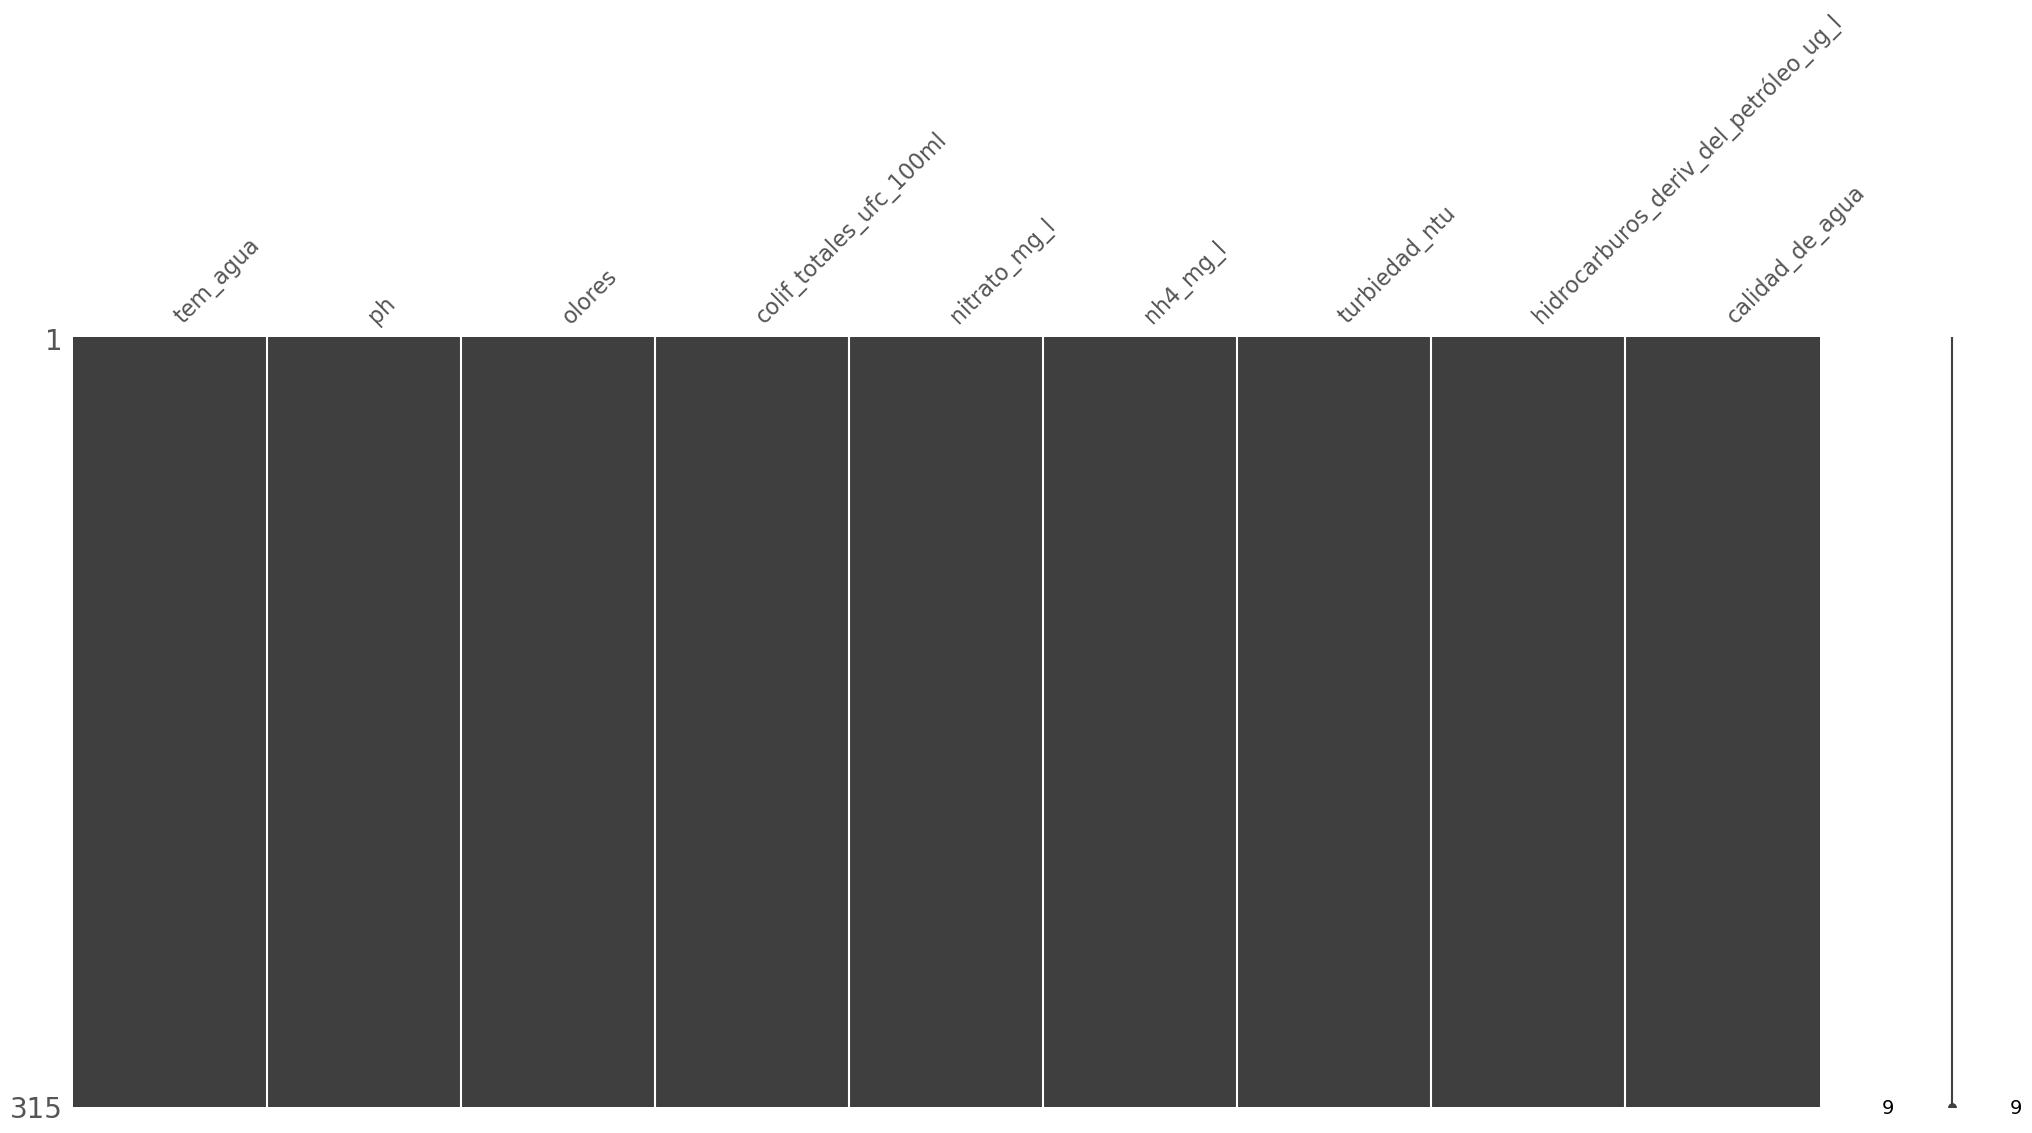

In [17]:
missingno.matrix(df)

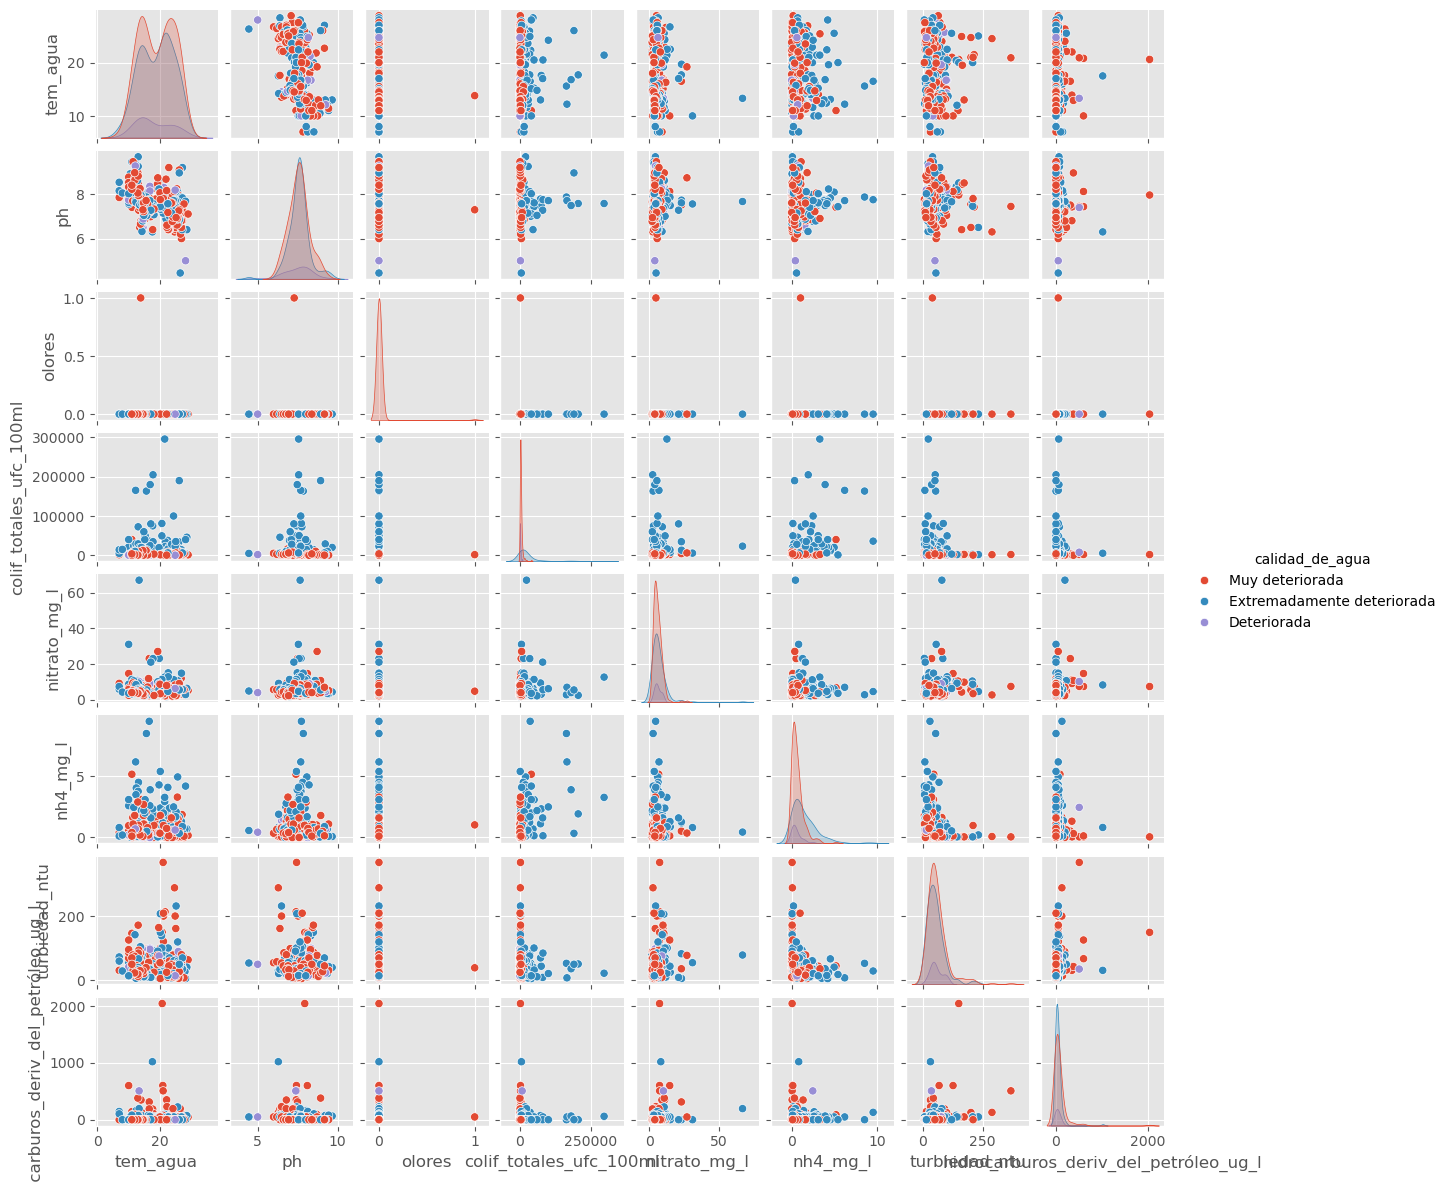

In [18]:
# Pair plot

pair_plot = sns.pairplot(data=df, hue='calidad_de_agua', height=1.5)

### Box plots

In [19]:
def box_plots(data, h_column, v_column):
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.boxplot(data=df, x=h_column, y=v_column, ax=ax)
    ax.set_xlabel("")
    ax.set_ylabel(v_column, fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)
    ax.set_title('Boxplot: {} VS Calidad de agua'.format(v_column), size=16, fontweight='bold')
    plt.show()

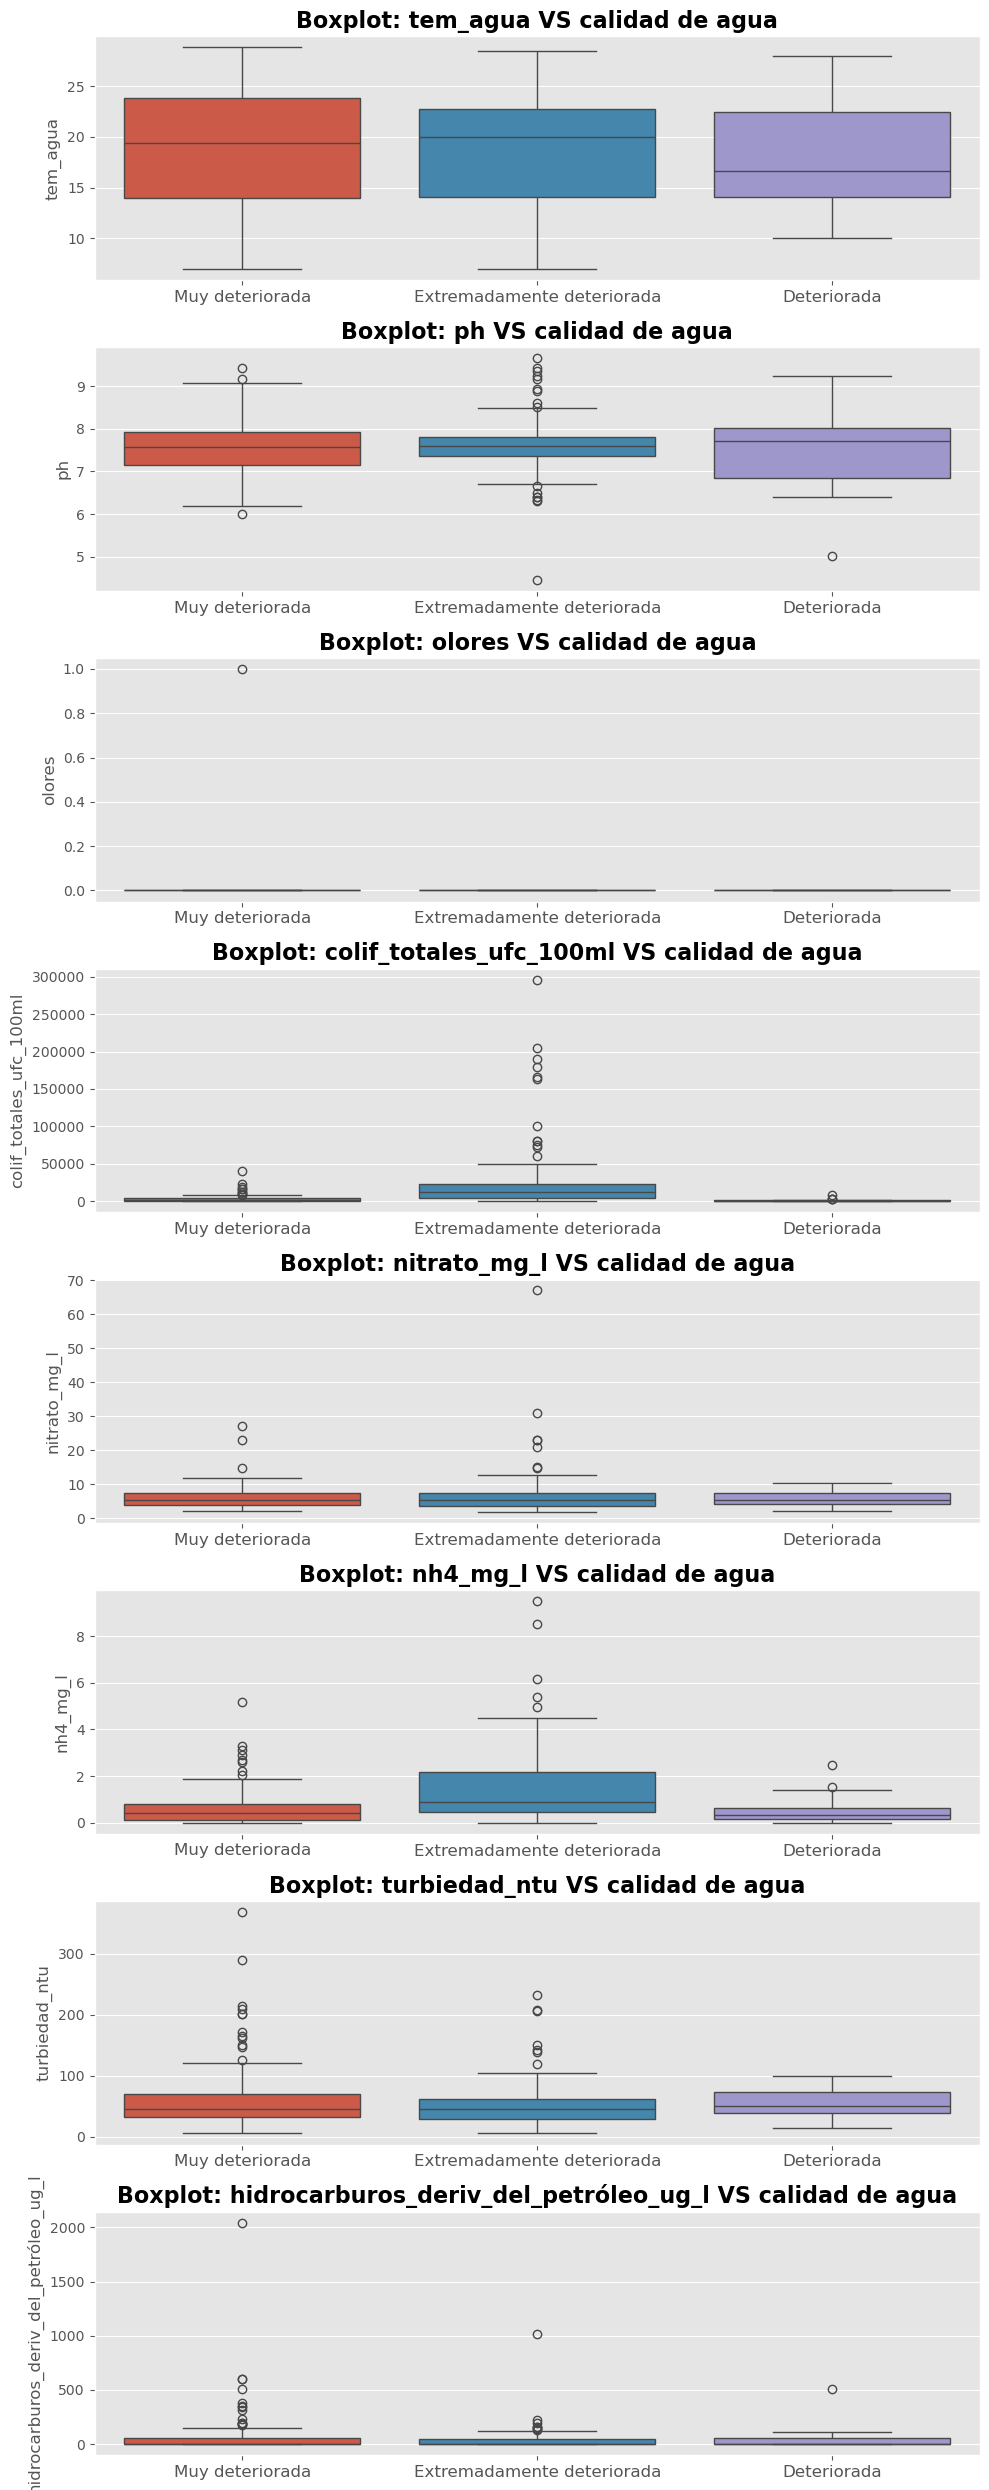

In [20]:
props = ['tem_agua', 'ph', 'olores','colif_totales_ufc_100ml',
       'nitrato_mg_l', 'nh4_mg_l', 'turbiedad_ntu','hidrocarburos_deriv_del_petróleo_ug_l']
fig, ax = plt.subplots(len(props),1, figsize=(10,25))

for axes, prop in zip(ax, props):
    sns.boxplot(data=df, x="calidad_de_agua", y=prop, ax=axes, hue="calidad_de_agua")
    axes.set_xlabel("")
    axes.set_ylabel(prop, fontsize=12)
    axes.set_xticklabels(axes.get_xticklabels(), fontsize=12)
    axes.set_title('Boxplot: {} VS calidad de agua'.format(prop), size=16, fontweight='bold')
plt.tight_layout()

 ### Matríz de Correlación

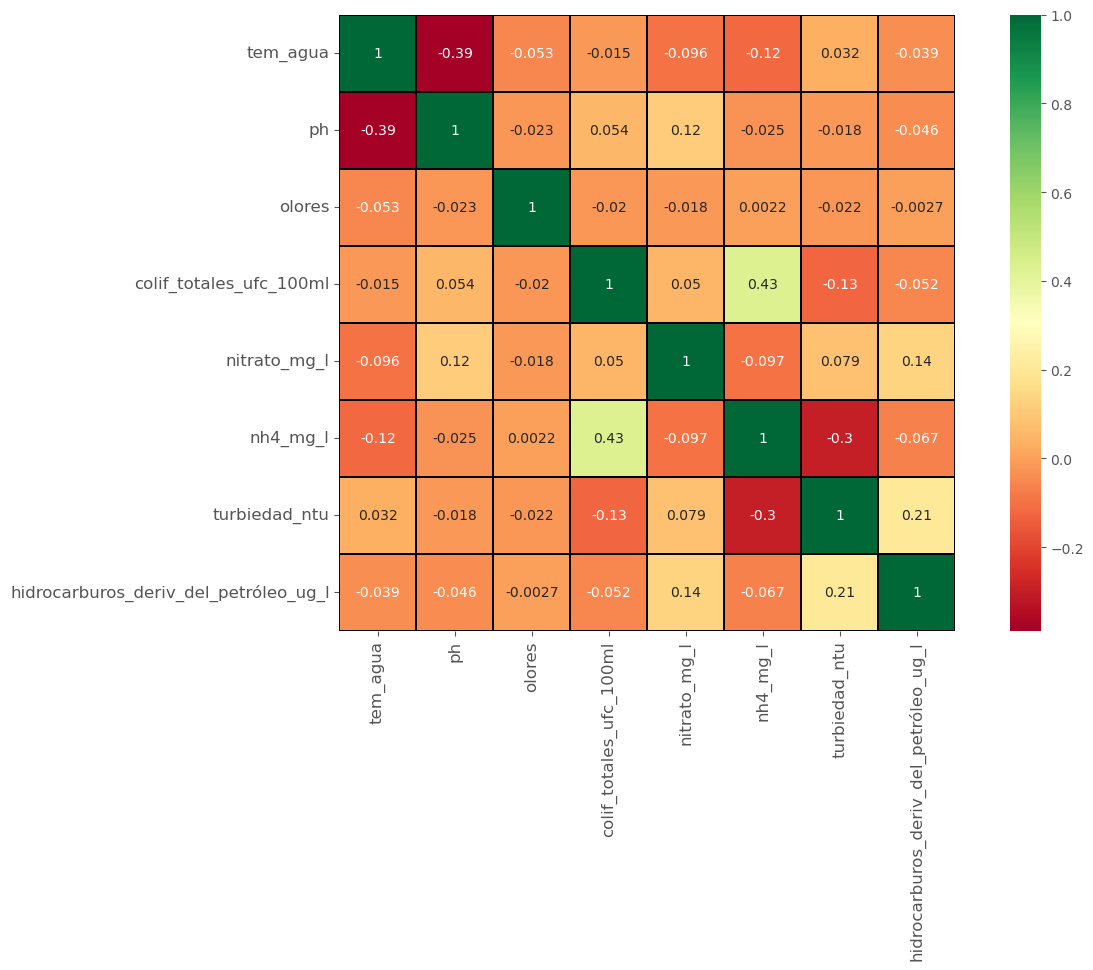

In [21]:
# Correlación de Pearson
corr = df.corr(numeric_only=True)

# Mapa de calor de las correlaciones
fig, ax = plt.subplots(figsize=(14,8))
sns.heatmap(data=corr, cmap='RdYlGn', annot=True, linewidths=0.01, linecolor='black', square=True, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=12)
plt.show()

## Selección de variables

In [22]:
X = df.iloc[:,:8].values 
y = df.iloc[:,-1] 

### División de datos y entrenamiento de modelos
El dataset se dividió:
##### 80% para entrenamiento y 20% para testeo

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [24]:
# Algoritmos de Machine Learning para clasificación
knn = KNeighborsClassifier()
decision_tree = DecisionTreeClassifier()
svc = SVC()
rf = RandomForestClassifier()

In [25]:
# Definición de los hyperparámetros para cada algoritmo
knn_params = {'n_neighbors': np.arange(1, 30)}
dt_params = {'max_depth': np.arange(2,20,1)}
svc_params = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
rf_params = {'max_depth': np.arange(5, 30, 1)}

In [26]:
# Función para entrenar cada algoritmo

def training_model(model, param_grid):
    model = GridSearchCV(model, param_grid=param_grid, scoring='accuracy')
    model.fit(X_train, y_train)
    return model

## KNN

In [27]:
knn_model = training_model(knn, knn_params)
knn_model.best_params_

{'n_neighbors': np.int64(19)}

In [28]:
knn_model_final = knn_model.best_estimator_.fit(X_train, y_train)

In [29]:
# Predicción en el conjunto de pruebas
y_pred_knn = knn_model_final.predict(X_test)

In [30]:
# Precisión del modelo
print(knn_model_final.score(X_train, y_train))
print(knn_model_final.score(X_test, y_test))

0.7222222222222222
0.6507936507936508


In [31]:
# Precisión
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(accuracy_knn)

0.6507936507936508


In [32]:
def evaluation_plot_knn(init, stop, step, algorithm):
    fig, ax = plt.subplots(figsize=(15,8))
    param = np.arange(init, stop, step) 
    train_accuracy = np.empty(len(param)) 
    test_accuracy = np.empty(len(param))
    for i, k in enumerate(param): 
        model = algorithm(n_neighbors=k)
        model.fit(X_train, y_train)
        train_accuracy[i] = model.score(X_train, y_train) 
        test_accuracy[i] = model.score(X_test, y_test)
    ax.plot(param, test_accuracy, label = 'Prueba') 
    ax.plot(param, train_accuracy, label = 'Entrenamiento') 
    plt.legend(fontsize=12) 
    ax.set_xlabel('K neighbors', size=12) 
    ax.set_ylabel('Accuracy')
    ax.set_title('Accuracy Vs K neighbors', size=16, fontweight='bold')
    plt.show()

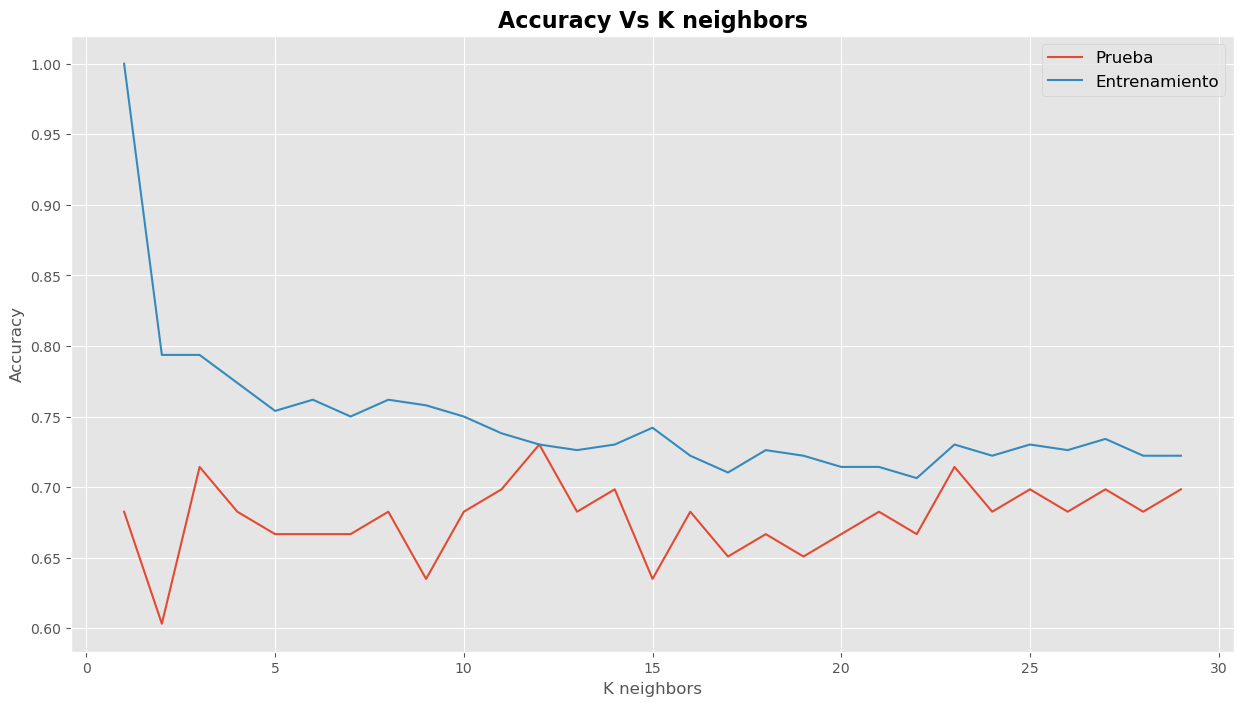

In [33]:
evaluation_plot_knn(1, 30, 1, KNeighborsClassifier)

## Decision Tree algorithm

In [34]:
# Decision tree algorithm
dt_model = training_model(decision_tree, dt_params)
dt_model.best_params_

{'max_depth': np.int64(2)}

In [35]:
dt_model_final = dt_model.best_estimator_.fit(X_train, y_train)

In [36]:
# Predicción en el conjunto de pruebas
y_pred_dt = dt_model_final.predict(X_test)

In [37]:
# Precisión del modelo
print(dt_model_final.score(X_train, y_train))
print(dt_model_final.score(X_test, y_test))

0.7222222222222222
0.6984126984126984


In [38]:
# Precisión
accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(accuracy_dt)

0.6984126984126984


In [39]:
def evaluation_plot_tree(init, stop, step, algorithm):
    fig, ax = plt.subplots(figsize=(15,8))
    max_depth = np.arange(init, stop, step) 
    train_accuracy = np.empty(len(max_depth)) 
    test_accuracy = np.empty(len(max_depth))
    for i, k in enumerate(max_depth): 
        Dt = DecisionTreeClassifier(max_depth=k) 
        Dt.fit(X_train, y_train)
        train_accuracy[i] = Dt.score(X_train, y_train) 
        test_accuracy[i] = Dt.score(X_test, y_test)
    ax.plot(max_depth, test_accuracy, label = 'Prueba') 
    ax.plot(max_depth, train_accuracy, label = 'Entrenamiento') 
    plt.legend(fontsize=12) 
    ax.set_xlabel('Max depth', size=12) 
    ax.set_ylabel('Accuracy')
    ax.set_title('Accuracy Vs Max depth', size=16, fontweight='bold')
    plt.show()

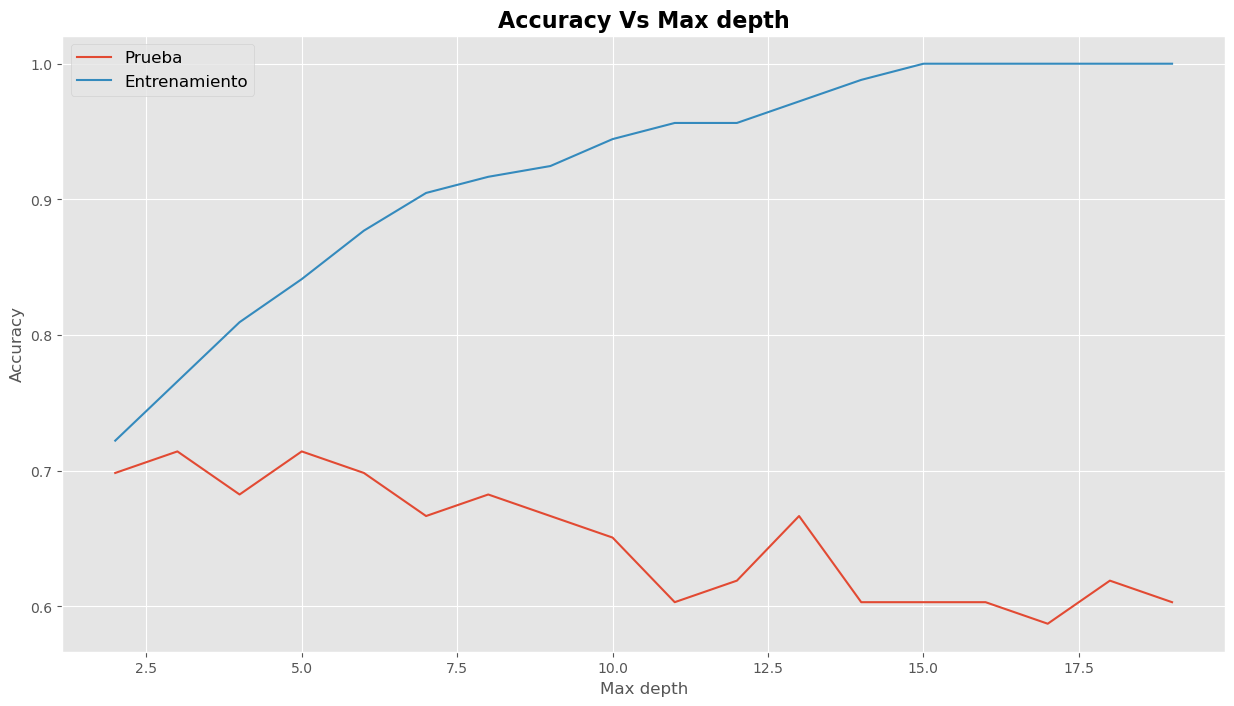

In [40]:
evaluation_plot_tree(2, 20, 1, DecisionTreeClassifier)

###  Vector Classifier algorithm

In [41]:
# Support vector classifier algorithm
svc_model = training_model(svc, svc_params)
svc_model.best_params_

{'C': 1}

In [42]:
svc_model_final = svc_model.best_estimator_.fit(X_train, y_train)

In [43]:
# Predicción en el conjunto de pruebas
y_pred_svc = svc_model_final.predict(X_test)

In [44]:
# Precisión del modelo
print(svc_model_final.score(X_train, y_train))
print(svc_model_final.score(X_test, y_test))

0.7142857142857143
0.6984126984126984


In [45]:
# Precisión
accuracy_svc = accuracy_score(y_test, y_pred_svc)
print(accuracy_svc)

0.6984126984126984


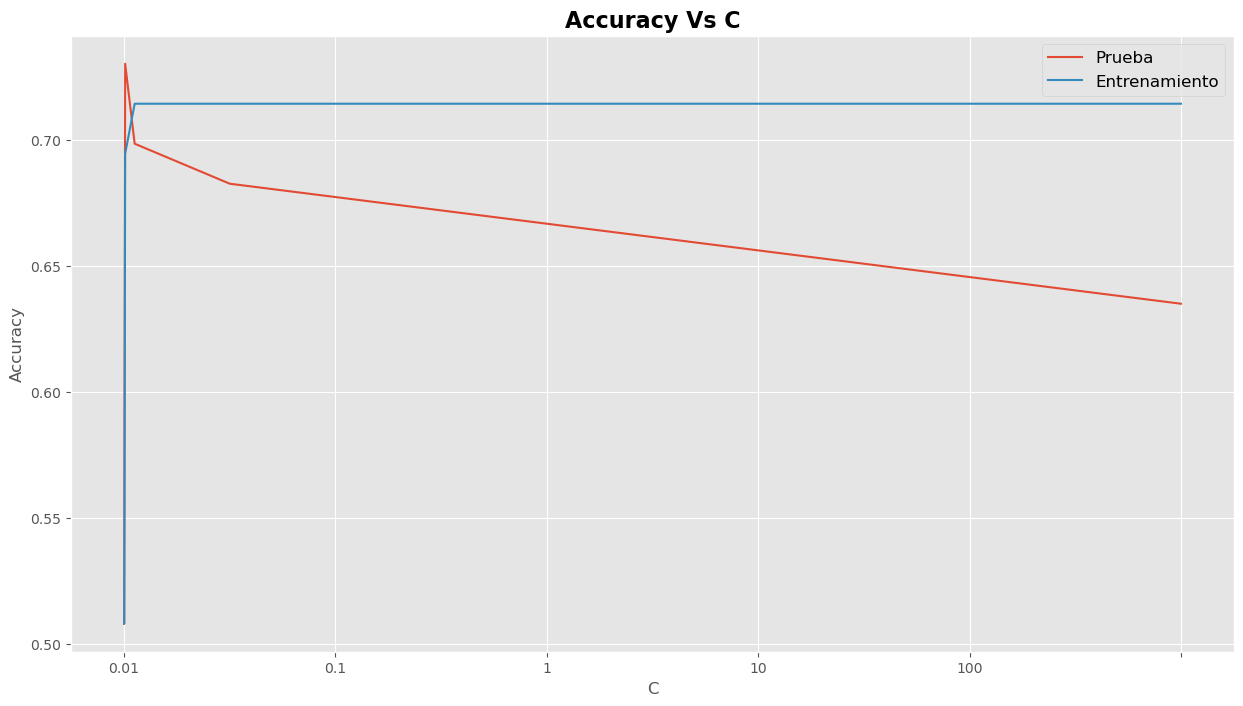

In [46]:
fig, ax = plt.subplots(figsize=(15,8))
C_values = [0.001, 0.01, 0.1, 1, 10, 100] 
train_accuracy = np.empty(len(C_values)) 
test_accuracy = np.empty(len(C_values))
for i, k in enumerate(C_values): 
    svc = SVC(C=k) 
    svc.fit(X_train, y_train)
    train_accuracy[i] = svc.score(X_train, y_train) 
    test_accuracy[i] = svc.score(X_test, y_test)
ax.plot(C_values, test_accuracy, label = 'Prueba') 
ax.plot(C_values, train_accuracy, label = 'Entrenamiento') 
plt.legend(fontsize=12) 
ax.set_xlabel('C', fontsize=12) 
ax.set_ylabel('Accuracy')
ax.set_xticklabels(C_values)
ax.set_title('Accuracy Vs C', size=16, fontweight='bold')
plt.show()

###  Random Forest algorithm

In [47]:
rf_model = training_model(rf, rf_params)
rf_model.best_params_

{'max_depth': np.int64(25)}

In [48]:
rf_model_final = rf_model.best_estimator_.fit(X_train, y_train)

In [49]:
# Predicción en el conjunto de pruebas
y_pred_rf = rf_model_final.predict(X_test)

In [50]:
# Precisión del modelo
print(rf_model_final.score(X_train, y_train))
print(rf_model_final.score(X_test, y_test))

1.0
0.6984126984126984


In [51]:
# Precisión
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(accuracy_rf)

0.6984126984126984


In [52]:
def evaluation_plot_forest(init, stop, step, algorithm):
    fig, ax = plt.subplots(figsize=(15,8))
    param = np.arange(init, stop, step) 
    train_accuracy = np.empty(len(param)) 
    test_accuracy = np.empty(len(param))
    for i, k in enumerate(param): 
        model = algorithm(max_depth=k) 
        model.fit(X_train, y_train)
        train_accuracy[i] = model.score(X_train, y_train) 
        test_accuracy[i] = model.score(X_test, y_test)
    ax.plot(param, test_accuracy, label = 'Prueba') 
    ax.plot(param, train_accuracy, label = 'Entrenamiento') 
    plt.legend(fontsize=12) 
    ax.set_xlabel('Max depth', fontsize=12) 
    ax.set_ylabel('Accuracy')
    ax.set_title('Accuracy Vs Max depth', size=16, fontweight='bold')
    plt.show()

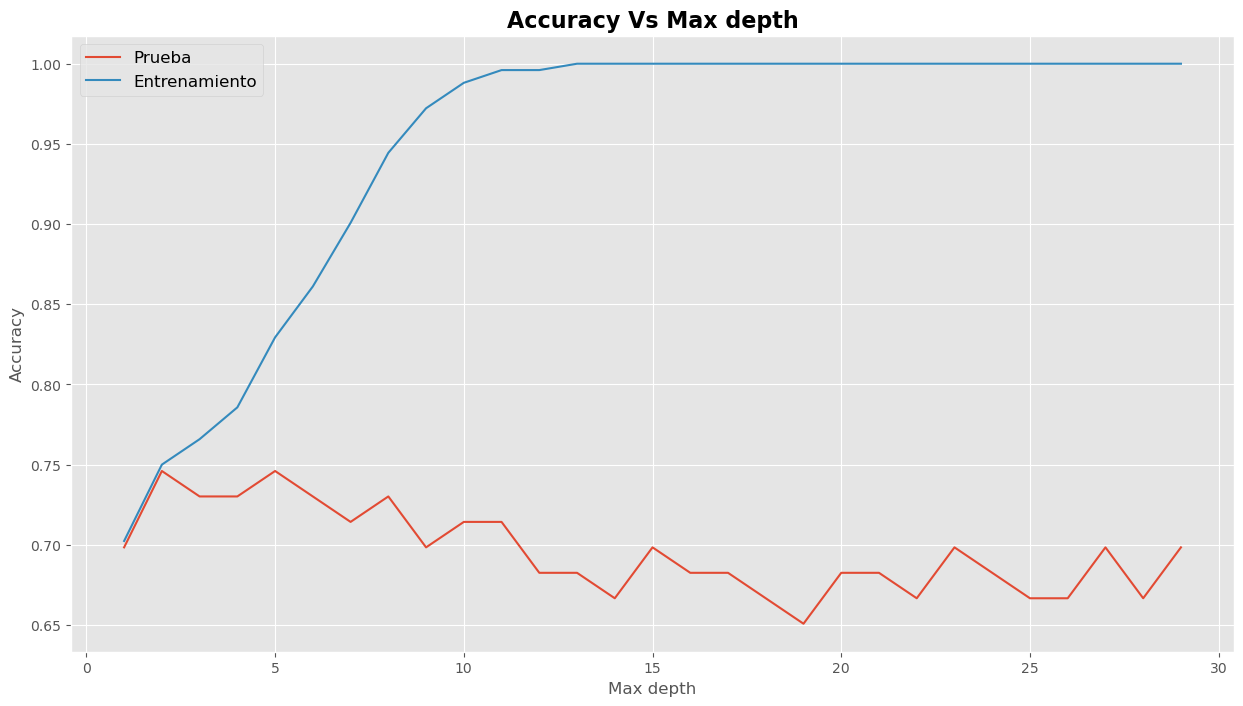

In [53]:
evaluation_plot_forest(1, 30, 1, RandomForestClassifier)

### Evaluación de los modelos

In [54]:
accuracy = [accuracy_knn, accuracy_dt, accuracy_svc, accuracy_rf]
algorithms = ['KNN', 'Decision Tree', 'SVC', 'Random Forest']

model_select = pd.DataFrame({'Modelo': algorithms, 'Precesión': accuracy})
model_select

,Modelo,Precesión
0,KNN,0.650794
1,Decision Tree,0.698413
2,SVC,0.698413
3,Random Forest,0.698413


In [55]:
def method_recommended(model, tem_agua, ph, olores, colif_totales_ufc_100ml, nitrato_mg_l, nh4_mg_l, turbiedad_ntu, hidrocarburos_deriv_del_petróleo_ug_l):
    predict = model.predict(np.array([tem_agua, ph, olores, colif_totales_ufc_100ml, nitrato_mg_l, nh4_mg_l, turbiedad_ntu, hidrocarburos_deriv_del_petróleo_ug_l]).reshape(1, -1))
    return print(f'El agua estudiada se encuentra: {predict[0]}')

In [56]:
predict_1 = method_recommended(rf_model_final, 20.8, 7.43, 0.0, 2110.0, 7.33, 0.05, 67.5, 602.0)
predict_1

El agua estudiada se encuentra: Muy deteriorada
